In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\sakil\Downloads\Groceries_dataset.csv.zip")
print(df.head())

   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


In [3]:
print("Shape of Dataset:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe(include='all'))

Shape of Dataset:
(38765, 3)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB

Statistical Summary:
        Member_number        Date itemDescription
count    38765.000000       38765           38765
unique            NaN         728             167
top               NaN  21-01-2015      whole milk
freq              NaN          96            2502
mean      3003.641868         NaN             NaN
std       1153.611031         NaN             NaN
min       1000.000000         NaN             NaN
25%       2002.000000         NaN             NaN
50%       3005.000000         NaN             NaN
75%       4007.000000         NaN         

In [5]:
print(df.isnull().sum())

Member_number      0
Date               0
itemDescription    0
dtype: int64


In [6]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows Before Removal:")
print(duplicate_count)

Duplicate Rows Before Removal:
759


In [7]:
df = df.drop_duplicates()

print("Duplicate Rows After Removal:")
print(df.duplicated().sum())

Duplicate Rows After Removal:
0


In [8]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.head()

C:\Users\sakil\AppData\Local\Temp\ipykernel_11464\3137090742.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


,Member_number,Date,itemDescription,Year,Month,Day
0,1808,2015-07-21,tropical fruit,2015,7,21
1,2552,2015-01-05,whole milk,2015,1,5
2,2300,2015-09-19,pip fruit,2015,9,19
3,1187,2015-12-12,other vegetables,2015,12,12
4,3037,2015-02-01,whole milk,2015,2,1


In [9]:
df.to_csv("cleaned_dataset.csv", index=False)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [10]:
print(df.describe(include='all'))

        Member_number                           Date itemDescription  \
count    38006.000000                          38006           38006   
unique            NaN                            NaN             167   
top               NaN                            NaN      whole milk   
freq              NaN                            NaN            2363   
mean      3003.361390  2015-01-08 22:17:51.115087104             NaN   
min       1000.000000            2014-01-01 00:00:00             NaN   
25%       2001.000000            2014-07-12 00:00:00             NaN   
50%       3005.000000            2015-01-19 00:00:00             NaN   
75%       4007.000000            2015-07-09 00:00:00             NaN   
max       5000.000000            2015-12-30 00:00:00             NaN   
std       1153.659151                            NaN             NaN   

                Year         Month           Day  
count   38006.000000  38006.000000  38006.000000  
unique           NaN           Na

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.head())

   Member_number       Date   itemDescription  Year  Month  Day
0           1808 2015-07-21    tropical fruit  2015      7   21
1           2552 2015-01-05        whole milk  2015      1    5
2           2300 2015-09-19         pip fruit  2015      9   19
3           1187 2015-12-12  other vegetables  2015     12   12
4           3037 2015-02-01        whole milk  2015      2    1


In [12]:
print("Unique Customers:")
print(df['Member_number'].nunique())
print("Unique Products:")
print(df['itemDescription'].nunique())

Unique Customers:
3898
Unique Products:
167


In [13]:
top_products = df['itemDescription'].value_counts().head(10)

print(top_products)

itemDescription
whole milk          2363
other vegetables    1827
rolls/buns          1646
soda                1453
yogurt              1285
root vegetables     1041
tropical fruit      1014
bottled water        908
sausage              903
citrus fruit         795
Name: count, dtype: int64


In [14]:
daily_sales = df.groupby('Day').size()

print(daily_sales)

Day
1     1239
2     1265
3     1359
4     1196
5     1200
6     1254
7     1226
8     1328
9     1162
10    1237
11    1284
12    1216
13    1318
14    1316
15    1218
16    1140
17    1149
18    1258
19    1255
20    1195
21    1315
22    1260
23    1250
24    1266
25    1199
26    1326
27    1300
28    1347
29    1097
30    1176
31     655
dtype: int64


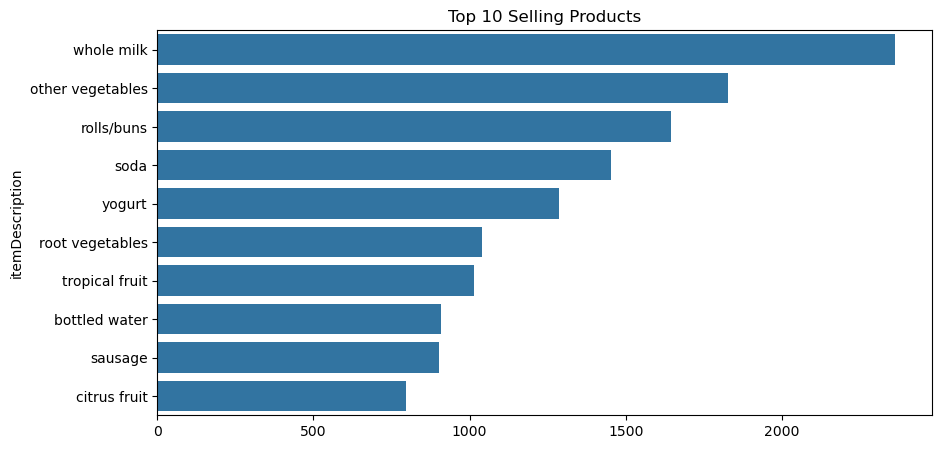

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Selling Products")
plt.show()

In [16]:
customer_freq = df.groupby(
    'Member_number'
).size()

print(customer_freq.describe())

count    3898.000000
mean        9.750128
std         5.185020
min         1.000000
25%         6.000000
50%         9.000000
75%        13.000000
max        35.000000
dtype: float64


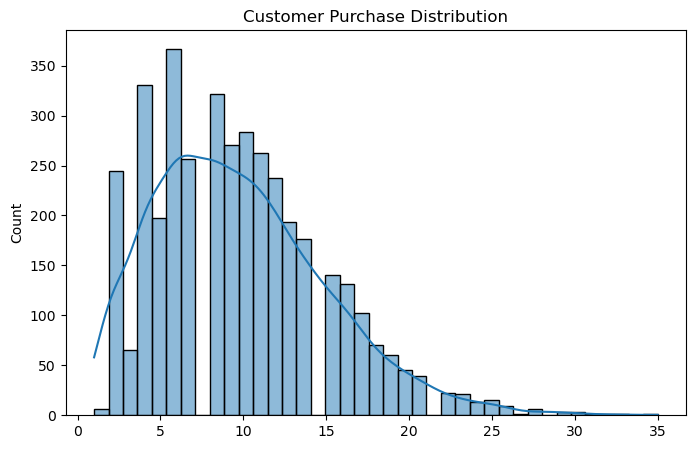

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_freq,
    kde=True
)

plt.title("Customer Purchase Distribution")

plt.show()

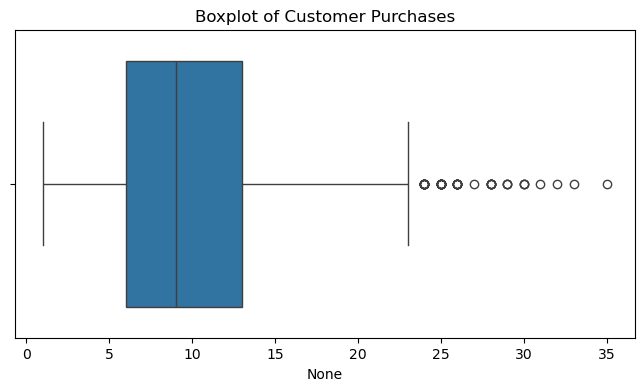

In [18]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=customer_freq
)

plt.title("Boxplot of Customer Purchases")

plt.show()

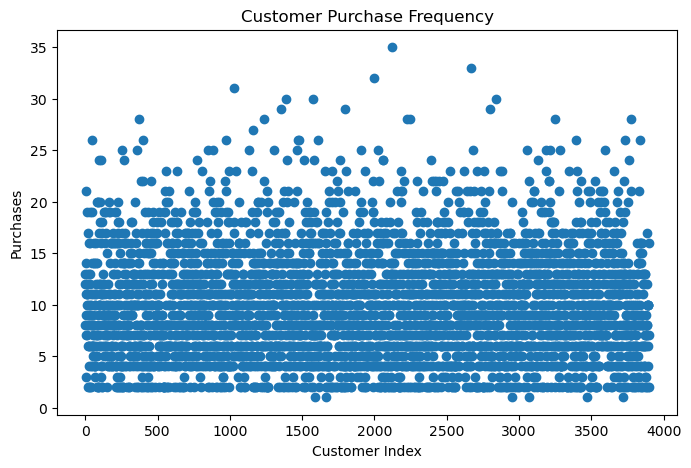

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    range(len(customer_freq)),
    customer_freq
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Customer Index")
plt.ylabel("Purchases")

plt.show()

In [20]:
monthly_sales = df.groupby(
    'Month'
).size()

print(monthly_sales)

Month
1     3250
2     2926
3     3055
4     3194
5     3348
6     3207
7     3240
8     3431
9     3002
10    3203
11    3193
12    2957
dtype: int64


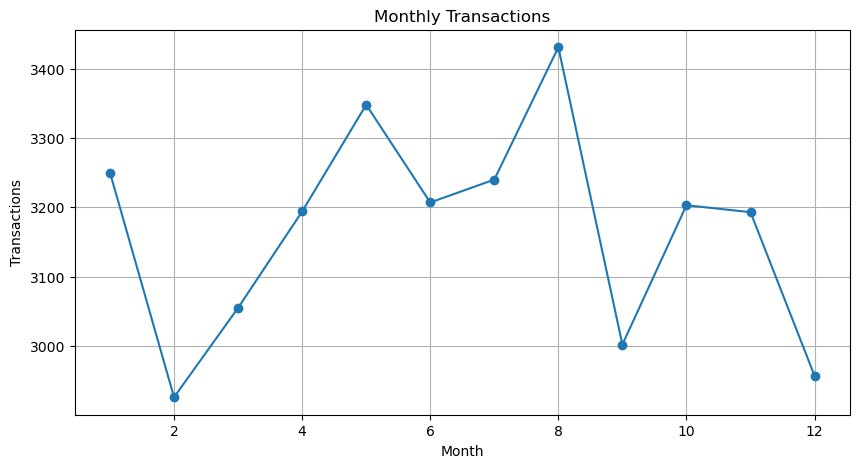

In [21]:
plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker='o'
)

plt.title("Monthly Transactions")
plt.ylabel("Transactions")

plt.grid()

plt.show()

In [22]:
yearly_sales = df.groupby(
    'Year'
).size()

print(yearly_sales)

Year
2014    18025
2015    19981
dtype: int64


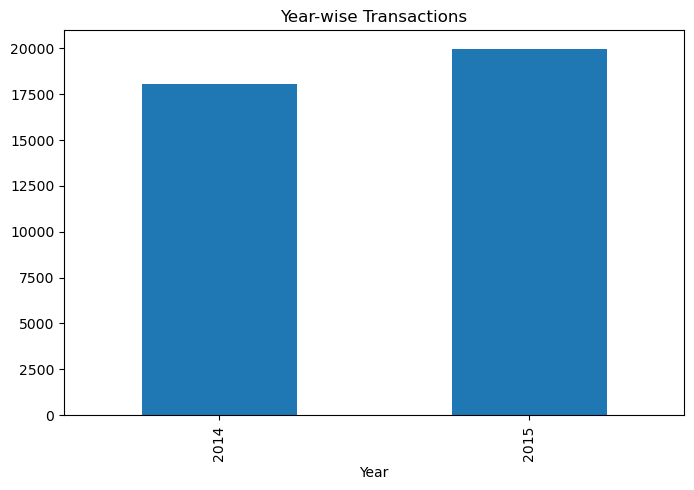

In [23]:
plt.figure(figsize=(8,5))

yearly_sales.plot(
    kind='bar'
)

plt.title("Year-wise Transactions")

plt.show()

In [24]:
top_customers = df.groupby(
    'Member_number'
).size().sort_values(
    ascending=False
).head(10)

print(top_customers)

Member_number
3180    35
3737    33
3050    32
2051    31
2433    30
3915    30
2625    30
2394    29
3872    29
2851    29
dtype: int64


In [25]:
customer_segment = pd.cut(
    customer_freq,
    bins=[0,10,20,50,100],
    labels=['Low','Medium','High','VIP']
)

print(customer_segment.value_counts())

Low       2345
Medium    1417
High       136
VIP          0
Name: count, dtype: int64


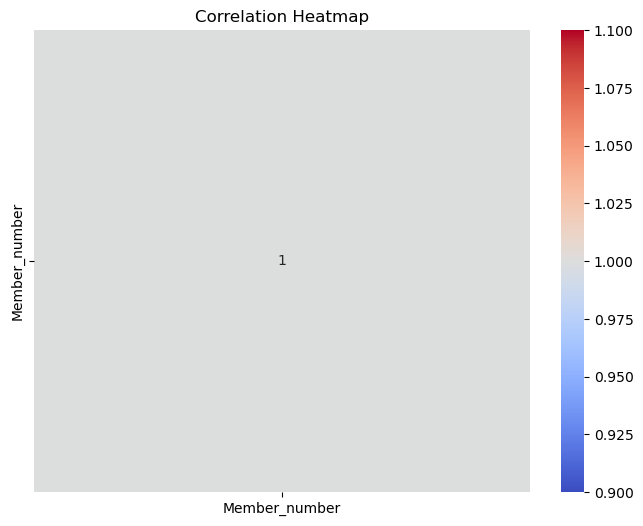

In [26]:
numeric_cols = df.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [27]:
X = np.array(
    monthly_sales.index
).reshape(-1,1)

y = monthly_sales.values

model = LinearRegression()

model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
future_months = np.array(
    [13,14,15]
).reshape(-1,1)

predictions = model.predict(
    future_months
)

for month,pred in zip(
    future_months,
    predictions
):
    print(
        "Month",
        month[0],
        ":",
        int(pred)
    )

Month 13 : 3156
Month 14 : 3155
Month 15 : 3153


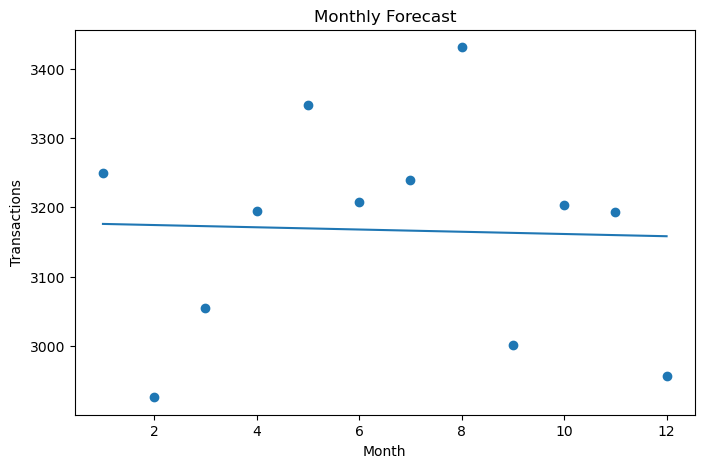

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(X,y)

plt.plot(
    X,
    model.predict(X)
)

plt.title("Monthly Forecast")

plt.xlabel("Month")
plt.ylabel("Transactions")

plt.show()